# NBA Position Classification with kNN and SVM


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Step 1: Load and merge the data

In [ ]:
import pandas as pd

perGame = pd.read_csv('gdrive/My Drive/03-04PGStats.csv')
advStats = pd.read_csv('gdrive/My Drive/03-04AdvStats.csv')

# Merge on player name
totStats = pd.merge(perGame, advStats, on='Player')
totStats = totStats[totStats['Player'].notna()]
totStats = totStats[totStats['Player'] != ' ']
totStats.set_index('Player', inplace=True)

print(totStats.shape)
totStats.head()

(360, 17)


,Pos_x,G_x,MP,FGA,3PA,3P%,Pos_y,G_y,3PAr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%
Player,,,,,,,,,,,,,,,,,
Tracy McGrady,SG,67.0,39.9,23.4,7.7,0.339,SG,67.0,0.328,3.9,13.3,8.5,28.3,1.8,1.1,9.1,33.2
Allen Iverson,SG,48.0,42.5,23.4,4.1,0.286,SG,48.0,0.177,2.0,8.2,5.1,34.4,3.1,0.2,13.6,35.3
Kevin Garnett,PF,82.0,39.4,19.6,0.5,0.256,PF,82.0,0.027,9.1,30.0,20.1,24.4,2.0,4.0,10.5,29.6
Peja Stojaković,SF,81.0,40.3,17.1,6.8,0.433,SF,81.0,0.400,3.2,14.1,8.8,9.1,1.7,0.3,8.9,23.9
Kobe Bryant,SG,65.0,37.6,18.1,3.3,0.327,SG,65.0,0.184,4.7,12.0,8.3,24.4,2.4,0.8,10.8,29.1


## Step 2: Filter to meaningful sample (min games and minutes)

In [ ]:
# Keep only players who actually played 20 games/15MPG
cleanStats = totStats[(totStats['MP'] >= 15) & (totStats['G_x'] >= 20)].copy()
cleanStats.drop(columns=['Pos_y', 'G_y'], inplace=True)

print(f"Players remaining: {len(cleanStats)}")
print(cleanStats['Pos_x'].value_counts())

Players remaining: 264
Pos_x
PF    58
SF    55
SG    54
PG    53
C     44
Name: count, dtype: int64


## Step 3: Quick look at the data

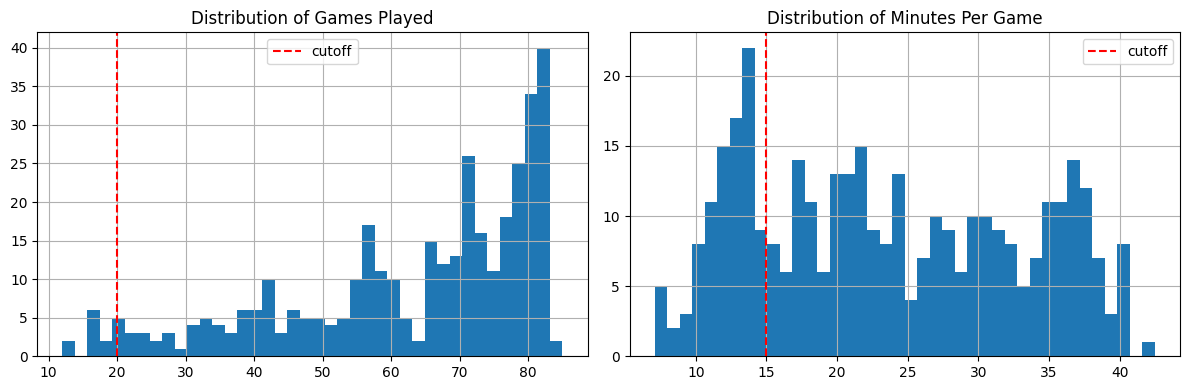

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

totStats['G_x'].hist(bins=40, ax=axes[0])
axes[0].set_title('Distribution of Games Played')
axes[0].axvline(20, color='red', linestyle='--', label='cutoff')
axes[0].legend()

totStats['MP'].hist(bins=40, ax=axes[1])
axes[1].set_title('Distribution of Minutes Per Game')
axes[1].axvline(15, color='red', linestyle='--', label='cutoff')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 4: Prepare features and labels



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Features: drop the position column, keep numeric stats
feature_cols = ['G_x', 'MP', 'FGA', '3PA', '3P%', '3PAr',
                'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%']

X = cleanStats[feature_cols].fillna(0)  # fill any missing with 0
y = cleanStats['Pos_x']                 # position is our target label

# Scale features to have mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 211
Test samples:     53


## Step 5: k-Nearest Neighbors (kNN)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Try different values of k
k_values = [1, 3, 5, 7, 9, 11]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc = accuracy_score(y_test, preds)
    knn_accuracies.append(acc)
    print(f"k={k:2d}  accuracy={acc:.3f}")

best_k = k_values[knn_accuracies.index(max(knn_accuracies))]
print(f"\nBest k: {best_k} with accuracy {max(knn_accuracies):.3f}")

k= 1  accuracy=0.491
k= 3  accuracy=0.566
k= 5  accuracy=0.585
k= 7  accuracy=0.585
k= 9  accuracy=0.604
k=11  accuracy=0.566

Best k: 9 with accuracy 0.604


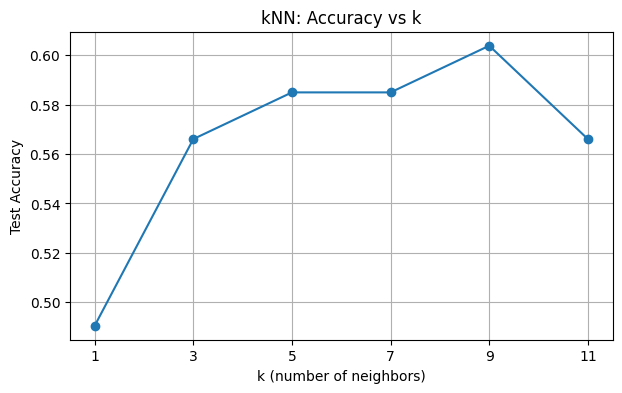

In [ ]:
# Plot accuracy vs k
plt.figure(figsize=(7, 4))
plt.plot(k_values, knn_accuracies, marker='o')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.title('kNN: Accuracy vs k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

=== kNN (k=9) Classification Report ===
              precision    recall  f1-score   support

           C       0.67      0.44      0.53         9
          PF       0.57      0.67      0.62        12
          PG       1.00      0.70      0.82        10
          SF       0.40      0.55      0.46        11
          SG       0.64      0.64      0.64        11

    accuracy                           0.60        53
   macro avg       0.65      0.60      0.61        53
weighted avg       0.65      0.60      0.61        53



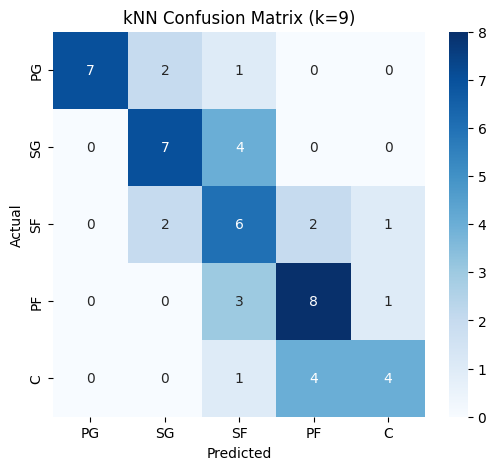

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Detailed report with the best k
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
knn_preds = best_knn.predict(X_test)

print(f"=== kNN (k={best_k}) Classification Report ===")
print(classification_report(y_test, knn_preds))

# Confusion matrix - rows=actual, columns=predicted
cm = confusion_matrix(y_test, knn_preds, labels=['PG','SG','SF','PF','C'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['PG','SG','SF','PF','C'],
            yticklabels=['PG','SG','SF','PF','C'], cmap='Blues')
plt.title(f'kNN Confusion Matrix (k={best_k})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Step 6: Support Vector Machine (SVM)


In [ ]:
from sklearn.svm import SVC

# Linear SVM — draws straight hyperplanes between classes
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
linear_preds = svm_linear.predict(X_test)
print("=== SVM (linear kernel) ===")
print(classification_report(y_test, linear_preds))

# RBF SVM — can draw curved boundaries, often works better in practice
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)
rbf_preds = svm_rbf.predict(X_test)
print("=== SVM (RBF kernel) ===")
print(classification_report(y_test, rbf_preds))

=== SVM (linear kernel) ===
              precision    recall  f1-score   support

           C       0.80      0.44      0.57         9
          PF       0.50      0.75      0.60        12
          PG       0.90      0.90      0.90        10
          SF       0.50      0.45      0.48        11
          SG       0.80      0.73      0.76        11

    accuracy                           0.66        53
   macro avg       0.70      0.66      0.66        53
weighted avg       0.69      0.66      0.66        53

=== SVM (RBF kernel) ===
              precision    recall  f1-score   support

           C       0.75      0.33      0.46         9
          PF       0.53      0.83      0.65        12
          PG       0.90      0.90      0.90        10
          SF       0.50      0.55      0.52        11
          SG       0.75      0.55      0.63        11

    accuracy                           0.64        53
   macro avg       0.69      0.63      0.63        53
weighted avg       0.68 

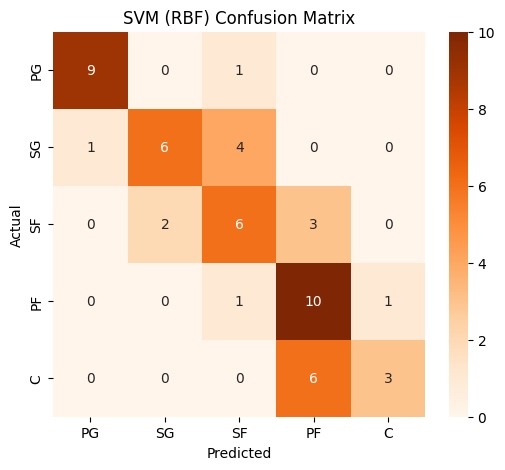

In [ ]:
# Confusion matrix for RBF SVM
cm_svm = confusion_matrix(y_test, rbf_preds, labels=['PG','SG','SF','PF','C'])
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', xticklabels=['PG','SG','SF','PF','C'],
            yticklabels=['PG','SG','SF','PF','C'], cmap='Oranges')
plt.title('SVM (RBF) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Step 7: Compare the models side by side

Model Comparison:
  kNN (k=9)             0.604
  SVM (linear)          0.660
  SVM (RBF)             0.642


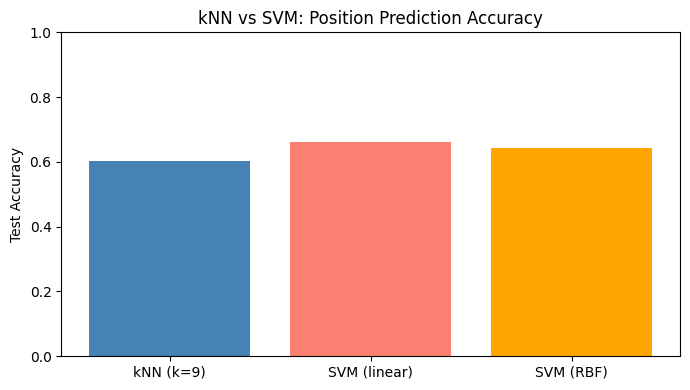

In [ ]:
results = {
    f'kNN (k={best_k})':        accuracy_score(y_test, knn_preds),
    'SVM (linear)':             accuracy_score(y_test, linear_preds),
    'SVM (RBF)':                accuracy_score(y_test, rbf_preds),
}

print("Model Comparison:")
for name, acc in results.items():
    print(f"  {name:20s}  {acc:.3f}")

# Bar chart
plt.figure(figsize=(7, 4))
plt.bar(results.keys(), results.values(), color=['steelblue', 'salmon', 'orange'])
plt.ylim(0, 1)
plt.ylabel('Test Accuracy')
plt.title('kNN vs SVM: Position Prediction Accuracy')
plt.tight_layout()
plt.show()